# **Preparasi Data dan Pelabelan Sentimen Ulasan Mobile JKN**
### **Periode Juni–Agustus 2026**

Tahap ini untuk memeriksa kualitas data dan melakukan
labeling manual terhadap sampel ulasan Mobile JKN periode
Juni–Agustus 2026.

Label sentimen yang digunakan:
- Positif
- Negatif
- Netral

## **1. Memuat Raw Data Hasil Scraping**

In [ ]:
# Menghubungkan Google Drive dan menyiapkan library yang digunakan
from google.colab import drive
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

drive.mount('/content/drive')

# Menggunakan folder dan nama file yang sudah ada di notebook
FOLDER_PROJECT = "/content/drive/MyDrive/DA PPKD/PBL"
PATH_DATA = os.path.join(FOLDER_PROJECT, "mobile_jkn_juni_agustus_2026.csv")
PATH_SAMPEL_1200 = os.path.join(FOLDER_PROJECT, "mobile_jkn_sampel_1200_tetap.csv")
PATH_FILE_LABELING = os.path.join(FOLDER_PROJECT, "mobile_jkn_sampel_1200_untuk_labeling.xlsx")
PATH_LABEL_MANUAL = os.path.join(FOLDER_PROJECT, "mobile_jkn_sampel_1200_berlabel.xlsx")
PATH_NETRAL_tambahan = os.path.join(FOLDER_PROJECT, "mobile_jkn_label_netral_manual_tambahan.xlsx")
PATH_FINAL_CSV = os.path.join(FOLDER_PROJECT, "mobile_jkn_label_manual_final.csv")

# Membaca raw data tanpa mengubah teks ulasan
df_raw = pd.read_csv(
    PATH_DATA, dtype={"id": "string", "teks": "string"}, keep_default_na=False
)
display(df_raw.head())
print("Jumlah total raw data:", len(df_raw))
print("Insight: Raw data ini menjadi sumber sampel awal dan tambahan netral.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,teks,rating,tanggal,jam
0,afc4dbfc-10a7-4be4-a703-7d18b2898a78,"Makin parah nih apk nya. Iuran udah di bayar, ...",2,2026-06-01,0
1,3bac7ee0-3beb-438c-b242-08bfe9547e9a,aplikasi JKN ini sangat mempermudah dalam pela...,5,2026-06-01,0
2,6dad03f2-eff6-4c20-8eea-cb3c3fa21030,APLIKASI KALAU LAGI URGENT DI BUTUHKAN MALAH O...,1,2026-06-01,1
3,52a1e12d-ea2a-4b1a-9a57-29136404c66e,Setiap kali mau daftar ke faskes tingkat lanju...,5,2026-06-01,1
4,c4e4a82c-89e0-40d1-b1ae-9a26200bd041,"ribet, tidak fleksibel dan sering error ☹️",1,2026-06-01,2


Jumlah total raw data: 12105
Insight: Raw data ini menjadi sumber sampel awal dan tambahan netral.


## **2. Pengambilan Sampel 1.200 Data untuk Pelabelan Manual**


In [ ]:
# Mengutamakan sampel 1200 yang sudah tersimpan
if os.path.exists(PATH_SAMPEL_1200):
    sampel_1200 = pd.read_csv(
        PATH_SAMPEL_1200,
        dtype={"id": "string", "teks": "string"},
        keep_default_na=False
    )

    print("Sampel tetap dibaca dari CSV yang sudah tersedia.")

else:
    # Menyiapkan data yang memiliki teks
    data_siap_sampel = df_raw.loc[
        df_raw["teks"].str.strip().ne("")
    ].copy()

    # Menyiapkan informasi bulan
    tanggal_sampel = pd.to_datetime(
        data_siap_sampel["tanggal"],
        errors="coerce"
    )

    data_siap_sampel["bulan"] = tanggal_sampel.dt.month.map({
        6: "Juni",
        7: "Juli",
        8: "Agustus"
    })

    data_siap_sampel["tanggal"] = tanggal_sampel.dt.strftime("%Y-%m-%d")

    # Mengambil 400 data dari masing-masing bulan
    daftar_sampel = []

    for bulan in ["Juni", "Juli", "Agustus"]:
        sampel_bulan = data_siap_sampel.loc[
            data_siap_sampel["bulan"].eq(bulan)
        ].sample(
            n=400,
            random_state=42
        )

        daftar_sampel.append(sampel_bulan)

    # Menggabungkan menjadi 1200 data
    sampel_1200 = pd.concat(
        daftar_sampel,
        ignore_index=True
    )

    # Mengacak urutan secara tetap
    sampel_1200 = sampel_1200.sample(
        frac=1,
        random_state=42
    ).reset_index(drop=True)

    # Menambahkan nomor sampel
    sampel_1200.insert(
        0,
        "nomor_sampel",
        range(1, len(sampel_1200) + 1)
    )

    # Menyimpan sampel tetap
    sampel_1200.to_csv(
        PATH_SAMPEL_1200,
        index=False,
        encoding="utf-8-sig"
    )

# =========================================================
# MEMBUAT FILE UNTUK LABELING MANUAL
# =========================================================

# Menyalin sampel 1200
df_labeling = sampel_1200.copy()

# Rating tidak diberikan kepada proses labeling manual
if "rating" in df_labeling.columns:
    df_labeling = df_labeling.drop(columns=["rating"])

# Menambahkan kolom label kosong
df_labeling["label"] = ""

# Membuat file Excel baru untuk proses labeling
df_labeling.to_excel(
    PATH_FILE_LABELING,
    index=False
)

print("File untuk labeling berhasil dibuat:")
print(PATH_FILE_LABELING)


# =========================================================
# MENAMPILKAN DATA
# =========================================================

display(df_labeling.head(10))

print(
    f"Menampilkan 10 baris pertama dari total "
    f"{len(df_labeling)} data untuk proses labeling."
)

Sampel tetap dibaca dari CSV yang sudah tersedia.
File untuk labeling berhasil dibuat:
/content/drive/MyDrive/DA PPKD/PBL/mobile_jkn_sampel_1200_untuk_labeling.xlsx


,nomor_sampel,id,teks,tanggal,jam,bulan,label
0,1,1d5db0cd-5049-4ef8-b8a7-a67fee796ecf,bagitulah,2026-08-14,15,Agustus,
1,2,7cb5e747-b566-4091-85d3-1334c10c9bf8,cepat mudah bagus terpercaya,2026-08-26,17,Agustus,
2,3,69287e3a-d28d-45e1-88fb-0d442b7e8815,knapa susah Skali verifikasi wajahnya apa haru...,2026-06-19,11,Juni,
3,4,02489b65-ca23-4caf-8efa-73ecbe02ae81,"Aplikasi tidak compatibel d ponsel saya, d pak...",2026-07-02,17,Juli,
4,5,20424ab0-b5b5-49d1-a381-35c20a54b526,"aplikasi gk jls. kode otp gak masuk"" emng dasa...",2026-06-20,14,Juni,
5,6,e0440ade-9502-407a-9e37-d81224222a75,"gabisa login terus, padahak udah beberapa kali...",2026-08-18,14,Agustus,
6,7,a430380e-3e33-4430-a95d-bde9fda8f09a,Biometrik nya susah banget di verifikasi.....k...,2026-06-15,18,Juni,
7,8,357e800c-ed19-41e9-adad-29fed4e66bff,kode OTP sms tidak bisa terkirim,2026-08-10,13,Agustus,
8,9,66202aaf-cbea-4339-87cf-d0a889f21b87,bagus lanjutkan,2026-07-14,14,Juli,
9,10,e59b1f32-8aa2-45ef-b9d9-ecca0ead0f74,tolong di perbaiki apk nya soal nya tidak bisa...,2026-08-27,8,Agustus,


Menampilkan 10 baris pertama dari total 1200 data untuk proses labeling.


Setelah data 1.200 sample tanpa label sudah tersedia di drive dengan nama **mobile_jkn_sampel_1200_untuk_labeling.xlsx**, saya melakukan pelabelan sentimen secara manual terhadap 1.200 data. Setelah proses pelabelan selesai, hasilnya diunggah ke Google Drive dengan nama **mobile_jkn_sampel_1200_berlabel.xlsx**. Selanjutnya, data tersebut dibaca dan ditampilkan kembali pada notebook untuk digunakan sebagai dataset berlabel manual



### **Membaca Hasil Pelabelan Manual 1.200 Data**

In [ ]:
# Membaca hasil label manual; file untuk labeling juga dapat dipakai jika sudah terisi
path_label_dibaca = PATH_LABEL_MANUAL if os.path.exists(PATH_LABEL_MANUAL) else PATH_FILE_LABELING
data_label = pd.read_excel(path_label_dibaca, dtype="string", keep_default_na=False)
data_label.columns = data_label.columns.str.strip().str.lower()
URUTAN_LABEL = ["positif", "negatif", "netral"]

# Memastikan seluruh 1.200 data sudah berlabel manual
if len(data_label) != 1200 or not data_label["label_manual"].isin(URUTAN_LABEL).all():
    raise ValueError("File harus berisi 1.200 data dengan label manual positif, negatif, atau netral yang sudah terisi.")

# Memastikan hasil labeling memakai sampel yang sama dan berasal dari raw data
if set(data_label["id"]) != set(sampel_1200["id"]) or not data_label["id"].isin(df_raw["id"]).all():
    raise ValueError("ID hasil manual labeling harus sama dengan sampel tetap dan tersedia di raw data.")

print("File hasil manual labeling:", path_label_dibaca)
print("Jumlah data berlabel manual:", len(data_label))
display(data_label.head())

File hasil manual labeling: /content/drive/MyDrive/DA PPKD/PBL/mobile_jkn_sampel_1200_berlabel.xlsx
Jumlah data berlabel manual: 1200


,nomor_sampel,id,teks,tanggal,jam,bulan,label_manual
0,1,1d5db0cd-5049-4ef8-b8a7-a67fee796ecf,bagitulah,2026-08-14,15,Agustus,netral
1,2,7cb5e747-b566-4091-85d3-1334c10c9bf8,cepat mudah bagus terpercaya,2026-08-26,17,Agustus,positif
2,3,69287e3a-d28d-45e1-88fb-0d442b7e8815,knapa susah Skali verifikasi wajahnya apa haru...,2026-06-19,11,Juni,negatif
3,4,02489b65-ca23-4caf-8efa-73ecbe02ae81,"Aplikasi tidak compatibel d ponsel saya, d pak...",2026-07-02,17,Juli,negatif
4,5,20424ab0-b5b5-49d1-a381-35c20a54b526,"aplikasi gk jls. kode otp gak masuk"" emng dasa...",2026-06-20,14,Juni,negatif


## **3. Distribusi Sentimen Hasil Pelabelan Awal**

Menampilkan jumlah, persentase, dan grafik sederhana untuk ketiga kelas.

,jumlah,persentase (%)
label_manual,,
positif,567,47.25
negatif,605,50.42
netral,28,2.33


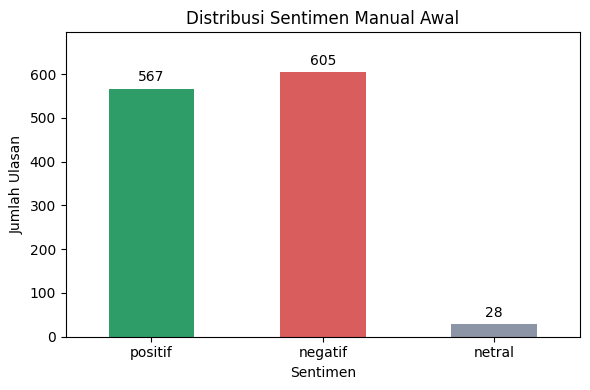

Insight: Label negatif paling banyak (605 data). Netral berjumlah 28 data (2.33%).


In [ ]:
# Menyeragamkan penulisan label tanpa menentukan label baru
WARNA_LABEL = ["#2E9D67", "#D95D5D", "#8B95A5"]
data_label["id"] = data_label["id"].str.strip()
data_label["label_manual"] = data_label["label_manual"].str.strip().str.lower()

# Menghitung distribusi label manual awal
jumlah_label = data_label["label_manual"].value_counts().reindex(URUTAN_LABEL, fill_value=0)
persentase_label = jumlah_label / len(data_label) * 100
display(pd.DataFrame({"jumlah": jumlah_label, "persentase (%)": persentase_label.round(2)}))

# Menampilkan grafik jumlah ulasan per sentimen
ax = jumlah_label.plot(kind="bar", figsize=(6, 4), color=WARNA_LABEL, rot=0)
ax.set(title="Distribusi Sentimen Manual Awal", xlabel="Sentimen", ylabel="Jumlah Ulasan")
ax.bar_label(ax.containers[0], padding=3)
ax.set_ylim(0, jumlah_label.max() * 1.15)
plt.tight_layout()
plt.show()

# Insight mengikuti jumlah yang benar-benar terbaca dari file
label_terbanyak = jumlah_label.idxmax()
print(f"Insight: Label {label_terbanyak} paling banyak ({jumlah_label[label_terbanyak]} data). "
      f"Netral berjumlah {jumlah_label['netral']} data ({persentase_label['netral']:.2f}%).")

**Evaluasi**

Pada hasil pelabelan awal, kelas netral hanya berjumlah 28 data **(2,33%)** sehingga representasinya jauh lebih rendah dibandingkan kelas positif dan negatif. Oleh karena itu, saya menambahkan sampel netral dari data yang belum digunakan. Jumlah tambahan mengikuti data yang tersedia, tanpa memaksakan jumlah kelas menjadi sama.

## **4. Menyiapkan Sisa Raw Data untuk Pencarian Tambahan Netral**

Mengeluarkan ID 1.200 sampel dari raw data. Tersisa 10.905 data yang dapat diperiksa manual.

In [ ]:
# Mengambil raw data di luar ID yang sudah digunakan pada data manual awal
df_sisa = df_raw.loc[~df_raw["id"].isin(data_label["id"])].copy()

print("Jumlah raw data sebelum pengurangan:", len(df_raw))
print("Jumlah data yang dikeluarkan:", len(df_raw) - len(df_sisa))
print("Jumlah sisa raw data:", len(df_sisa))
display(df_sisa.head())
print(f"Insight: {len(df_sisa)} ulasan di luar data manual awal tersedia sebagai sumber tambahan netral.")

Jumlah raw data sebelum pengurangan: 12105
Jumlah data yang dikeluarkan: 1200
Jumlah sisa raw data: 10905


,id,teks,rating,tanggal,jam
0,afc4dbfc-10a7-4be4-a703-7d18b2898a78,"Makin parah nih apk nya. Iuran udah di bayar, ...",2,2026-06-01,0
1,3bac7ee0-3beb-438c-b242-08bfe9547e9a,aplikasi JKN ini sangat mempermudah dalam pela...,5,2026-06-01,0
2,6dad03f2-eff6-4c20-8eea-cb3c3fa21030,APLIKASI KALAU LAGI URGENT DI BUTUHKAN MALAH O...,1,2026-06-01,1
3,52a1e12d-ea2a-4b1a-9a57-29136404c66e,Setiap kali mau daftar ke faskes tingkat lanju...,5,2026-06-01,1
4,c4e4a82c-89e0-40d1-b1ae-9a26200bd041,"ribet, tidak fleksibel dan sering error ☹️",1,2026-06-01,2


Insight: 10905 ulasan di luar data manual awal tersedia sebagai sumber tambahan netral.


Selanjutnya, saya melakukan pengecekan dan pelabelan secara manual terhadap data sisa dari data raw untuk memperoleh tambahan sampel sentimen netral. Dari proses tersebut, diperoleh sejumlah data yang teridentifikasi sebagai sentimen netral. Data hasil pelabelan kemudian diunggah ke Google Drive untuk digabungkan dengan dataset sampel berlabel manual sebelumnya.


### **Membaca Hasil Pelabelan Manual Tambahan Netral**

In [ ]:
# Membaca file tambahan netral yang sudah tersedia
data_netral = pd.read_excel(PATH_NETRAL_tambahan, dtype="string", keep_default_na=False)
data_netral.columns = data_netral.columns.str.strip().str.lower()
data_netral = data_netral.rename(columns={"label": "label_manual", "label_sentimen": "label_manual"})
data_netral["id"] = data_netral["id"].str.strip()
data_netral["label_manual"] = data_netral["label_manual"].str.strip().str.lower()

print("Jumlah seluruh baris dalam file tambahan:", len(data_netral))

# Mengambil baris yang benar-benar memiliki label manual netral
netral_berlabel = data_netral.loc[data_netral["label_manual"].eq("netral")].copy()
tambahan_netral = (
    netral_berlabel.loc[netral_berlabel["id"].isin(df_sisa["id"])].drop_duplicates(subset="id").copy()
)

print("Jumlah baris berlabel netral:", len(netral_berlabel))
print("Jumlah netral dari sisa raw yang akan ditambahkan:", len(tambahan_netral))
display(tambahan_netral.head())

Jumlah seluruh baris dalam file tambahan: 235
Jumlah baris berlabel netral: 235
Jumlah netral dari sisa raw yang akan ditambahkan: 235


,id,teks,tanggal,jam,label_manual
0,195ccc41-e39f-4424-a613-c2ec506f58fb,Lanjutkan,2026-06-01 00:00:00,7,netral
1,1955e5bc-af6e-4ac5-93ee-fee95f6dac95,coba dulu,2026-06-01 00:00:00,10,netral
2,a4671e31-7767-408b-ab3f-b5263b08fdc5,mudah2an ga ribet,2026-06-01 00:00:00,12,netral
3,1d39d6c7-4ece-43a8-9229-fa3812e175cb,baru mau daftar antrian,2026-06-01 00:00:00,19,netral
4,6a83b368-ec49-4f90-8ec9-e9c5a7387ae9,semoga lebih baik kedepannya aamiin,2026-06-01 00:00:00,19,netral


## **5. Menggabungkan Data Manual Awal dan Netral Tambahan**


In [ ]:
# Menggabungkan label manual awal dan label manual netral tambahan
label_awal = data_label[["id", "label_manual"]]
label_tambahan = tambahan_netral[["id", "label_manual"]]
gabungan_label = pd.concat([label_awal, label_tambahan], ignore_index=True)
gabungan_label = gabungan_label.rename(columns={"label_manual": "label_sentimen"})

# Mempertahankan metadata dan kolom bulan seperti output notebook lama
referensi_raw = df_raw.copy()
referensi_raw["bulan"] = pd.to_datetime(referensi_raw["tanggal"]).dt.month.map(
    {6: "Juni", 7: "Juli", 8: "Agustus"}
)
kolom_info_raw = ["id", "teks", "rating", "tanggal", "jam", "bulan"]
if "sumber" in referensi_raw.columns:
    kolom_info_raw.append("sumber")

# Mengambil metadata asli berdasarkan ID; setiap ID hanya boleh muncul sekali
df_final = gabungan_label.merge(
    referensi_raw[kolom_info_raw], on="id", how="left", validate="one_to_one"
)
df_final = (
    df_final[kolom_info_raw + ["label_sentimen"]]
    .sort_values("id").reset_index(drop=True)
)

print("Jumlah label manual awal:", len(data_label))
print("Jumlah netral tambahan:", len(tambahan_netral))
print("Jumlah total setelah penggabungan:", len(df_final))
display(df_final.head())

Jumlah label manual awal: 1200
Jumlah netral tambahan: 235
Jumlah total setelah penggabungan: 1435


,id,teks,rating,tanggal,jam,bulan,label_sentimen
0,000168e5-f4a4-49c5-93fd-35e3e3ada76c,aplikasi membantu,5,2026-07-21,21,Juli,positif
1,002a28f5-1509-429a-add1-ac64cca1b65f,"apk jelek, sampah, gw gk bisa daftar, kode otp...",1,2026-07-02,18,Juli,negatif
2,006020aa-5cc7-4654-9621-28573d91cb14,efektifitas mantaf,5,2026-08-14,16,Agustus,positif
3,00909726-a0e8-4c2f-bff8-aeb1c6eb25de,aplikasi ga jelas ngirim kode otp ga bisa bisa,1,2026-08-10,1,Agustus,negatif
4,00a7f08c-e6d2-45b7-8ed9-6b319caf400f,aplikasi gagal tiap verifikasi force close sampah,1,2026-06-18,18,Juni,negatif


### **Distribusi Sentimen Dataset Manual Final**

Membandingkan jumlah setiap kelas sebelum dan sesudah penambahan netral.

,jumlah_awal,tambahan,jumlah_final,persentase_final (%)
positif,567,0,567,39.51
negatif,605,0,605,42.16
netral,28,235,263,18.33


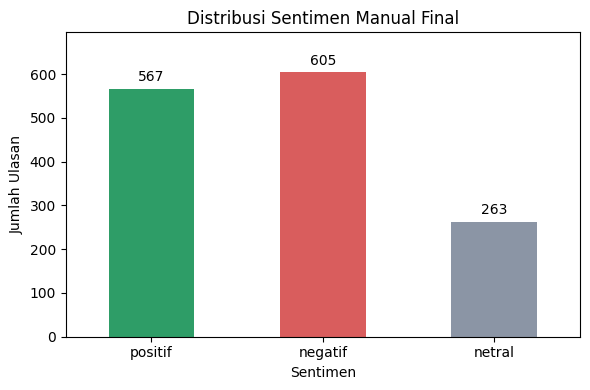

Insight: Netral bertambah 235 data, dari 28 (2.33%) menjadi 263 (18.33%). Jumlah positif dan negatif tetap.


In [ ]:
# Membandingkan distribusi awal dan akhir
jumlah_label_final = df_final["label_sentimen"].value_counts().reindex(URUTAN_LABEL, fill_value=0)
persentase_label_final = jumlah_label_final / len(df_final) * 100
ringkasan_label_final = pd.DataFrame({
    "jumlah_awal": jumlah_label,
    "tambahan": jumlah_label_final - jumlah_label,
    "jumlah_final": jumlah_label_final,
    "persentase_final (%)": persentase_label_final.round(2)
})
display(ringkasan_label_final)

# Menampilkan grafik distribusi setelah penambahan netral
ax = jumlah_label_final.plot(kind="bar", figsize=(6, 4), color=WARNA_LABEL, rot=0)
ax.set(title="Distribusi Sentimen Manual Final", xlabel="Sentimen", ylabel="Jumlah Ulasan")
ax.bar_label(ax.containers[0], padding=3)
ax.set_ylim(0, jumlah_label_final.max() * 1.15)
plt.tight_layout()
plt.show()

# Menjelaskan perubahan berdasarkan hasil penggabungan
print(f"Insight: Netral bertambah {len(tambahan_netral)} data, dari "
      f"{jumlah_label['netral']} ({persentase_label['netral']:.2f}%) menjadi "
      f"{jumlah_label_final['netral']} ({persentase_label_final['netral']:.2f}%). "
      "Jumlah positif dan negatif tetap.")

## **6. Menyimpan Dataset Label Manual Final**


In [ ]:
# Membaca CSV final yang sudah ada atau menyimpan hasil penggabungan pertama
if os.path.exists(PATH_FINAL_CSV):
    df_simpan = pd.read_csv(
        PATH_FINAL_CSV, dtype={"id": "string", "teks": "string"}, keep_default_na=False
    )
    print("CSV final sudah tersedia; ringkasan berikut berasal dari file tersebut.")
else:
    df_simpan = df_final.copy()
    df_simpan.to_csv(PATH_FINAL_CSV, index=False, encoding="utf-8-sig", mode="x")
    print("CSV label manual final berhasil disimpan.")

# Menampilkan file hasil, jumlah data, dan distribusi label final
print("Path file hasil:", PATH_FINAL_CSV)
print("Jumlah data final:", len(df_simpan))
display(
    df_simpan["label_sentimen"].value_counts().reindex(URUTAN_LABEL, fill_value=0).to_frame("jumlah")
)

CSV final sudah tersedia; ringkasan berikut berasal dari file tersebut.
Path file hasil: /content/drive/MyDrive/DA PPKD/PBL/mobile_jkn_label_manual_final.csv
Jumlah data final: 1435


,jumlah
label_sentimen,
positif,567
negatif,605
netral,263
